# Overfitting & Regularization Techniques


## 1. The Core Problem — Why Do Models Fail on New Data?

We built Linear Regression and Logistic Regression models. We trained them on a training set and evaluated them on a test set. But we left an important question only partially answered: **why does a model sometimes perform great on training data but poorly on new data?**

This is the most fundamental problem in machine learning. It comes down to three scenarios:

### Underfitting (High Bias)

The model is **too simple** to capture the real patterns in the data. Think of trying to fit a straight line through data that follows a curve. The model performs poorly on **both** the training data and new data because it has not learned enough.

Signs of underfitting:
- Low training accuracy / high training error
- Low test accuracy / high test error
- Both scores are similarly bad

### Overfitting (High Variance)

The model is **too complex** and starts memorizing the training data — including its noise and random fluctuations. It performs brilliantly on the training data but falls apart on new, unseen data because it has learned patterns that do not actually generalize.

Think of a student who memorizes every answer in the textbook but cannot solve a slightly different question on the exam. They have "overfit" to the textbook.

Signs of overfitting:
- High training accuracy / low training error
- Significantly lower test accuracy / higher test error
- A **large gap** between training and test performance

### Good Fit (The Sweet Spot)

The model has learned the real underlying patterns without memorizing noise. It generalizes well to new data.

Signs of a good fit:
- Reasonably high training accuracy
- Test accuracy close to training accuracy
- Small gap between the two

## 2. The Bias-Variance Trade-Off

This is one of the most important concepts in all of machine learning. Every model's error on new data can be decomposed into three parts:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

**Bias** is the error introduced by approximating a complex real-world problem with a simple model. High bias means the model makes strong (and wrong) assumptions. A straight line fit to a curved relationship has high bias.

**Variance** is the error introduced by the model being too sensitive to the specific training data. High variance means the model changes drastically if you train it on a slightly different dataset. A very complex model that memorizes training data has high variance.

**Irreducible noise** is the randomness inherent in the data itself — no model can eliminate this.

The trade-off: as you increase model complexity, bias decreases but variance increases. As you decrease model complexity, variance decreases but bias increases. The goal is to find the **sweet spot** where the sum of bias and variance is minimized.

**Regularization** is one of the most effective tools for navigating this trade-off. It works by adding a penalty for model complexity, pushing the model toward simpler solutions that generalize better.

## 3. Setup and Imports

**Task:** Import all required libraries.

In [6]:
# Import numpy, pandas, matplotlib.pyplot, seaborn

# From sklearn.model_selection import train_test_split

# From sklearn.preprocessing import PolynomialFeatures, StandardScaler

# From sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
#                                    LogisticRegression, RidgeClassifier)

# From sklearn.metrics import mean_squared_error, r2_score,
#                              accuracy_score, classification_report

# From sklearn.pipeline import make_pipeline

# Set seaborn style and random seed (42)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   LogisticRegression, RidgeCV, LassoCV)
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, classification_report)
from sklearn.pipeline import make_pipeline

sns.set_style('whitegrid')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


## 4. Seeing Overfitting in Action — A Visual Demo

The best way to understand overfitting is to **see** it. We will create a simple 1D dataset with a known pattern (a sine wave) plus some noise. Then we will fit polynomial models of increasing complexity and watch what happens.

Why a sine wave? Because we **know** the true underlying function. This means we can directly compare what the model learns versus what the truth actually is. In real-world problems we never know the true function — but this controlled experiment builds the intuition that will guide us.

### 4.1 Generate Synthetic Data

We generate 30 points from a sine curve and add random Gaussian noise with standard deviation 0.3. The noise simulates real-world measurement error — the kind of randomness that exists in every dataset. The model's job is to learn the sine wave, **not** the noise.

In [7]:
# Set random seed for reproducibility
# Generate 30 random x values between 0 and 2*pi using np.random.uniform
# Sort them for clean plotting: x = np.sort(...)
# Compute y = sin(x) + Gaussian noise (mean=0, std=0.3)
# Print the number of samples
np.random.seed(42)

x = np.sort(np.random.uniform(0, 2 * np.pi, 30))
y = np.sin(x) + np.random.normal(0, 0.3, size=len(x))

print(f"Generated {len(x)} synthetic data points")
print(f"x range: [{x.min():.2f}, {x.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")
print(f"True function: sin(x)")
print(f"Noise: Gaussian with mean=0, std=0.3")

Generated 30 synthetic data points
x range: [0.13, 6.09]
y range: [-1.49, 1.39]
True function: sin(x)
Noise: Gaussian with mean=0, std=0.3


### 4.2 Fit Polynomials of Degree 1, 5, and 20

Now comes the key experiment. We will fit three polynomial models to this data:

- **Degree 1** (a straight line) — This model has only 2 parameters (slope and intercept). A straight line simply cannot represent a sine wave. This is **underfitting** — the model is too simple.

- **Degree 5** — This model has 6 parameters. It has enough flexibility to approximate the smooth curves in a sine wave without chasing every noisy data point. This should be a **good fit**.

- **Degree 20** — This model has 21 parameters, nearly as many as we have data points (30). It has so much flexibility that it can wiggle and twist to pass through (or very close to) every single training point — including the noise. This is **overfitting**.

We use `make_pipeline` from Scikit-learn to chain `PolynomialFeatures` (which generates the polynomial terms like $x^2, x^3, \ldots$) with `LinearRegression` (which fits the weights). We also create a smooth array of 200 x-values for plotting clean prediction curves.

In [10]:
x_smooth = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
x_train = x.reshape(-1, 1)

degrees = [1, 5, 20]
labels = ['Underfitting', 'Good Fit', 'Overfitting']
predictions = {}
scores = {}

for deg in degrees:
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(x_train, y)
    predictions[deg] = pipe.predict(x_smooth)
    scores[deg] = pipe.score(x_train, y)

print("Training R² for each polynomial degree:")
print("-" * 40)
for deg, label in zip(degrees, labels):
    print(f"  Degree {deg:2d} ({label:12s}): R² = {scores[deg]:.4f}")

Training R² for each polynomial degree:
----------------------------------------
  Degree  1 (Underfitting): R² = 0.4607
  Degree  5 (Good Fit    ): R² = 0.8863
  Degree 20 (Overfitting ): R² = 0.8414


**What to observe in the output above:** Notice how the training R² increases with degree. Degree 20 will have an R² very close to 1.0 — it fits the training data almost perfectly. But remember, this includes fitting the **noise**, not just the signal. A perfect training score is actually a **warning sign**, not a success.

### 4.3 Visualize Underfitting, Good Fit, and Overfitting

Now let us plot all three fits side by side. In each subplot we show:
- The **blue dots** are our 30 noisy training points
- The **green dashed line** is the true sine function — the pattern we want the model to learn
- The **red solid line** is what the polynomial model actually learned

The closer the red line is to the green line (not to the blue dots), the better the model has learned the **true** pattern.

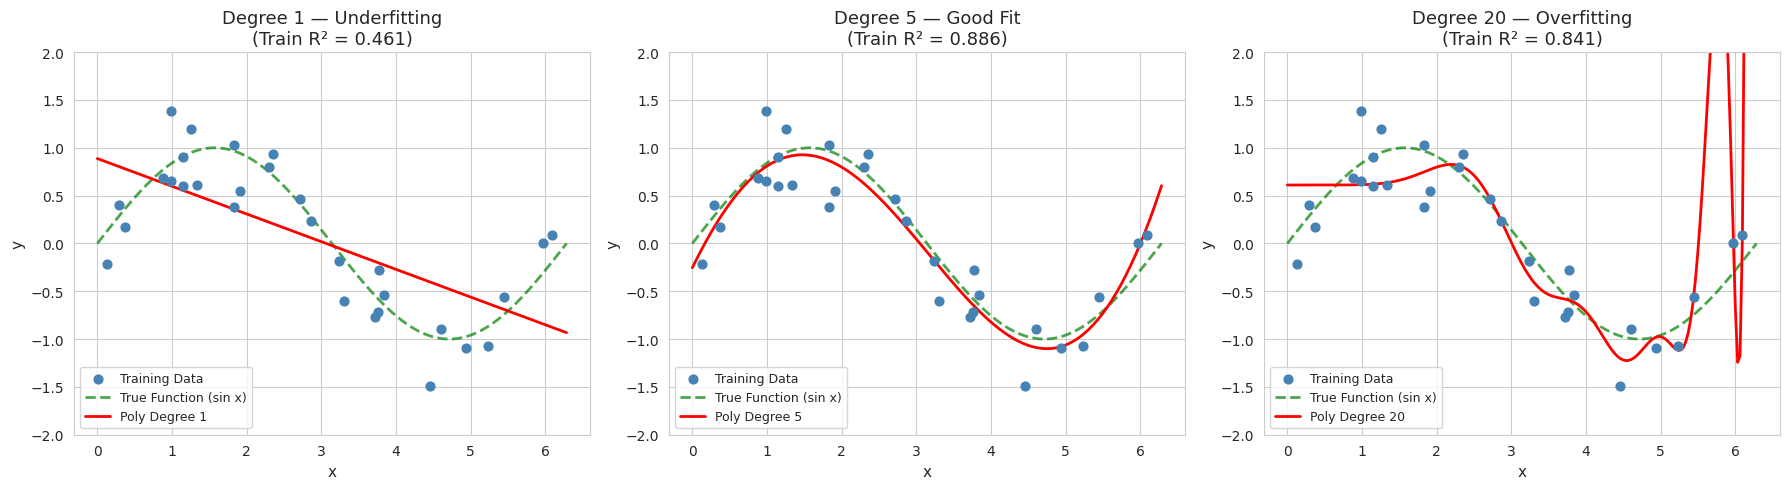

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (deg, label) in enumerate(zip(degrees, labels)):
    axes[i].scatter(x, y, color='steelblue', s=40, zorder=5, label='Training Data')
    axes[i].plot(x_smooth, np.sin(x_smooth), '--', color='green',
                 linewidth=2, label='True Function (sin x)', alpha=0.7)
    axes[i].plot(x_smooth, predictions[deg], '-', color='red',
                 linewidth=2, label=f'Poly Degree {deg}')
    axes[i].set_title(f'Degree {deg} — {label}\n(Train R² = {scores[deg]:.3f})',
                       fontsize=13)
    axes[i].set_ylim(-2, 2)
    axes[i].set_xlabel('x', fontsize=11)
    axes[i].set_ylabel('y', fontsize=11)
    axes[i].legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

**What to observe:**

- **Degree 1 (left):** The red line is straight — it cannot follow the curve at all. The model has completely missed the sine wave pattern. This is **underfitting**. The model is too simple. Its training R² is low.

- **Degree 5 (center):** The red line closely follows the green dashed line (the true sine wave). It captures the general up-and-down pattern without chasing individual noisy points. This is a **good fit**. It has learned the signal, not the noise.

- **Degree 20 (right):** The red line goes wild — it oscillates violently between data points, creating extreme peaks and valleys that have nothing to do with the true sine wave. The model has memorized every noisy training point. Its training R² is nearly perfect, but if we tested it on new data, it would fail spectacularly. This is **overfitting**.


## 5. What is Regularization?

We have seen the problem — overfitting. Now let us talk about one of the most powerful solutions: **regularization**.

The core idea is simple: we **modify the cost function** to add a penalty for large weights. This discourages the model from becoming overly complex.

Without regularization (standard Linear Regression):

$$\text{Cost} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$

The model is free to make the weights as large as it wants to minimize the error — which is exactly what leads to overfitting.

With regularization, we add a **penalty term**:

$$\text{Cost} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \lambda \cdot \text{Penalty}(\text{weights})$$

The parameter $\lambda$ (called **alpha** in Scikit-learn) controls the **strength** of the penalty:
- $\lambda = 0$ → no regularization (standard model)
- Small $\lambda$ → mild regularization
- Large $\lambda$ → strong regularization (model becomes very simple, risks underfitting)

The three main types of regularization differ in **how they define the penalty**.

## 6. Ridge Regression (L2 Regularization)

Ridge Regression adds the **sum of squared weights** as the penalty:

$$\text{Cost}_{\text{Ridge}} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \alpha \sum w_j^2$$

What does this do?
- It **shrinks** all coefficients toward zero, but never exactly to zero
- Large weights are penalized more heavily (because squaring amplifies large values)
- The model becomes smoother and less sensitive to individual data points

**When to use Ridge:**
- When you believe most features are useful but some may have inflated coefficients
- When you have multicollinearity (correlated features)
- When you want to keep all features in the model but control their influence

### 6.1 Ridge on Our Polynomial Example

Let us apply Ridge to the degree-20 polynomial that was overfitting. We will try different alpha values and see how regularization tames the wild oscillations.

**Task:** Fit Ridge regression with degree-20 polynomials at different alpha values.

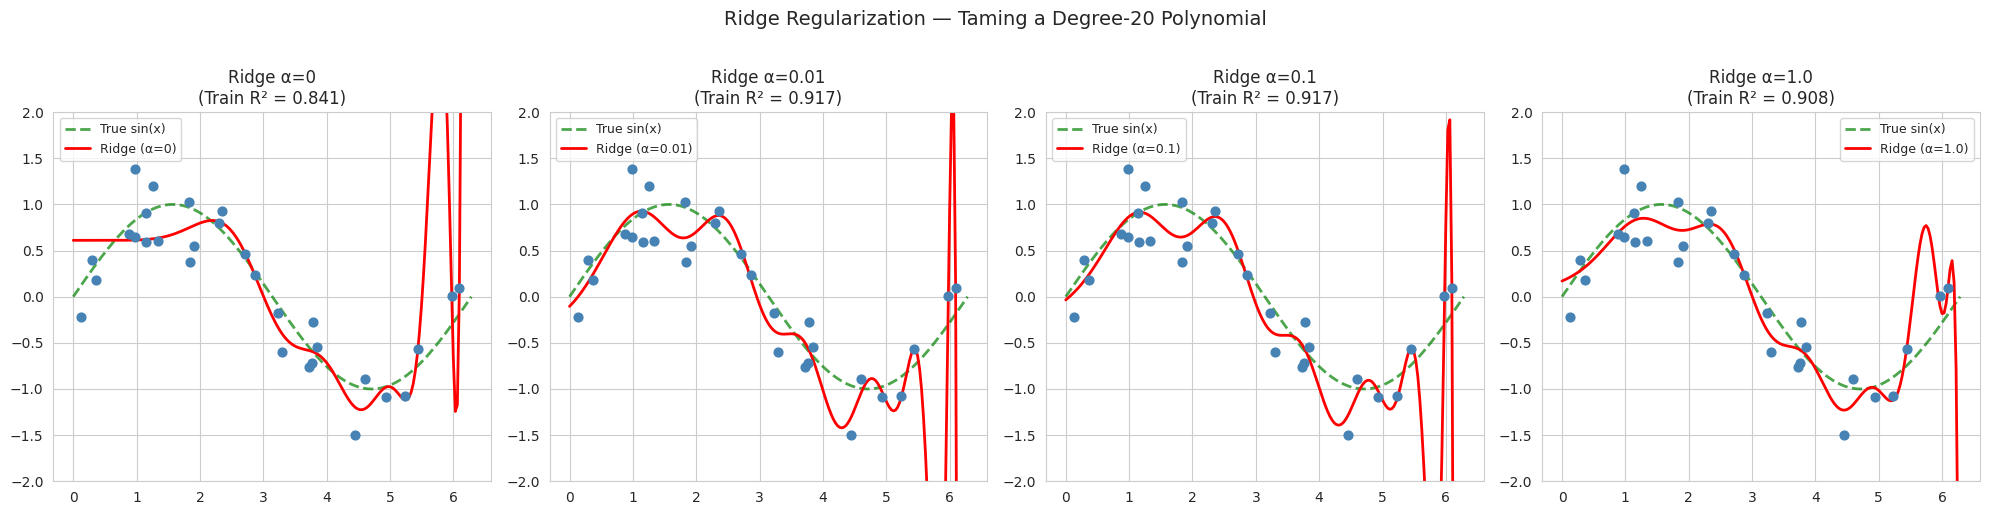

In [12]:
alphas_ridge = [0, 0.01, 0.1, 1.0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, alpha in enumerate(alphas_ridge):
    if alpha == 0:
        pipe = make_pipeline(PolynomialFeatures(20), LinearRegression())
    else:
        pipe = make_pipeline(PolynomialFeatures(20), Ridge(alpha=alpha))

    pipe.fit(x_train, y)
    y_smooth = pipe.predict(x_smooth)
    train_r2 = pipe.score(x_train, y)

    axes[i].scatter(x, y, color='steelblue', s=40, zorder=5)
    axes[i].plot(x_smooth, np.sin(x_smooth), '--', color='green',
                 linewidth=2, alpha=0.7, label='True sin(x)')
    axes[i].plot(x_smooth, y_smooth, '-', color='red', linewidth=2,
                 label=f'Ridge (α={alpha})')
    axes[i].set_title(f'Ridge α={alpha}\n(Train R² = {train_r2:.3f})', fontsize=12)
    axes[i].set_ylim(-2, 2)
    axes[i].legend(fontsize=9)

plt.suptitle('Ridge Regularization — Taming a Degree-20 Polynomial', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**What to observe:**

- **α=0 (no regularization):** This is the same wild degree-20 polynomial we saw earlier. The model oscillates violently because it has no penalty for using extreme weight values.

- **α=0.01 (light regularization):** The worst oscillations have been calmed down. The model is still flexible but the penalty is gently discouraging the most extreme weights. Notice the curve is already closer to the true sine.

- **α=0.1 (moderate regularization):** The curve is now much smoother. It follows the sine wave pattern well. The penalty has effectively told the model: "you can use 20 polynomial terms, but you cannot go crazy with the weights." This is close to an ideal fit.

- **α=1.0 (strong regularization):** The curve is very smooth — perhaps even a bit too smooth in places. If we increased alpha further, we would start underfitting. This shows the other side of the trade-off.

The training R² **decreases** as alpha increases — but that is exactly the point. We are trading a small amount of training performance for much better generalization. The model with α=0 has the highest training R² but would be the worst on new data.


## 7. Lasso Regression (L1 Regularization)

Lasso Regression adds the **sum of absolute values of weights** as the penalty:

$$\text{Cost}_{\text{Lasso}} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \alpha \sum |w_j|$$

What does this do differently from Ridge?
- Lasso can shrink coefficients **exactly to zero** — effectively removing features from the model
- This makes Lasso a built-in **feature selection** method
- With enough regularization, only the most important features survive

**Why does L1 produce zeros but L2 does not?** This is a geometric argument. The L1 penalty creates a diamond-shaped constraint region, and the optimal solution is more likely to land on a corner of the diamond (where some weights are zero). The L2 penalty creates a circular constraint region, so the optimal solution lands on the smooth surface (where weights are small but not zero).

**When to use Lasso:**
- When you suspect only a few features are truly important
- When you want automatic feature selection
- When you have many features and want a sparse, interpretable model

### 7.1 Lasso on a Real Dataset — California Housing

Let us see Lasso in action on the California Housing dataset from Day 45. We will watch how it zeros out less important features as alpha increases.

**Task:** Load the data, scale it, and fit Lasso with different alpha values.

In [13]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X_reg = housing.data
y_reg = housing.target

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc = scaler_reg.transform(X_reg_test)

print(f"California Housing loaded")
print(f"  Training set: {X_reg_train_sc.shape[0]} samples, {X_reg_train_sc.shape[1]} features")
print(f"  Test set:     {X_reg_test_sc.shape[0]} samples")
print(f"  Features: {list(X_reg.columns)}")

California Housing loaded
  Training set: 16512 samples, 8 features
  Test set:     4128 samples
  Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Now we fit Lasso at four different alpha values and observe what happens to the features. The key thing to watch is the **Non-Zero** and **Zeroed Out** columns — as alpha increases, Lasso aggressively drops features by setting their coefficients to exactly zero.

We also print the per-feature details at α=0.1 so you can see exactly which features were KEPT and which were DROPPED.

In [14]:
lasso_alphas = [0.001, 0.01, 0.1, 1.0]

print(f"{'Alpha':<10} {'Train R²':>10} {'Test R²':>10} {'Non-Zero':>10} {'Zeroed Out':>12}")
print("-" * 55)

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_reg_train_sc, y_reg_train)

    train_r2 = lasso.score(X_reg_train_sc, y_reg_train)
    test_r2 = lasso.score(X_reg_test_sc, y_reg_test)
    n_nonzero = np.sum(lasso.coef_ != 0)
    n_zero = np.sum(lasso.coef_ == 0)

    print(f"{alpha:<10} {train_r2:>10.4f} {test_r2:>10.4f} {n_nonzero:>10} {n_zero:>12}")

print("\n--- Feature details at α=0.1 ---")
lasso_demo = Lasso(alpha=0.1, max_iter=10000)
lasso_demo.fit(X_reg_train_sc, y_reg_train)
for name, coef in zip(X_reg.columns, lasso_demo.coef_):
    status = "KEPT" if coef != 0 else "DROPPED"
    print(f"  {name:18s}: {coef:+.4f}  [{status}]")

Alpha        Train R²    Test R²   Non-Zero   Zeroed Out
-------------------------------------------------------
0.001          0.6125     0.5769          8            0
0.01           0.6085     0.5816          7            1
0.1            0.4974     0.4814          3            5
1.0            0.0000    -0.0002          0            8

--- Feature details at α=0.1 ---
  MedInc            : +0.7106  [KEPT]
  HouseAge          : +0.1065  [KEPT]
  AveRooms          : -0.0000  [DROPPED]
  AveBedrms         : +0.0000  [DROPPED]
  Population        : -0.0000  [DROPPED]
  AveOccup          : -0.0000  [DROPPED]
  Latitude          : -0.0115  [KEPT]
  Longitude         : -0.0000  [DROPPED]


**What to observe**

- **α=0.001 (very light):** Almost no regularization effect. All 8 features survive. The model behaves nearly identically to standard Linear Regression.

- **α=0.01:** The penalty starts to bite. Check if any features have already been dropped. The test R² might actually be similar to (or even slightly better than) α=0.001 — removing noisy features can help.

- **α=0.1:** Several features have been zeroed out. Look at which ones remain — they should be the features we identified as important in Day 45 (like MedInc). The model is now simpler and more interpretable.

- **α=1.0 (very strong):** Most or all features are zeroed out. The model is overly constrained — regularized into uselessness. R² drops significantly. This is underfitting caused by too much regularization.

The feature details at α=0.1 show exactly which features were KEPT vs DROPPED. This is Lasso's superpower — it does not just shrink coefficients, it **eliminates** features entirely.

### 7.2 Visualizing Lasso Feature Elimination

Let us create a clear visual showing how many features survive at each alpha level.

**Task:** Plot a coefficient path — how each coefficient changes as alpha increases.

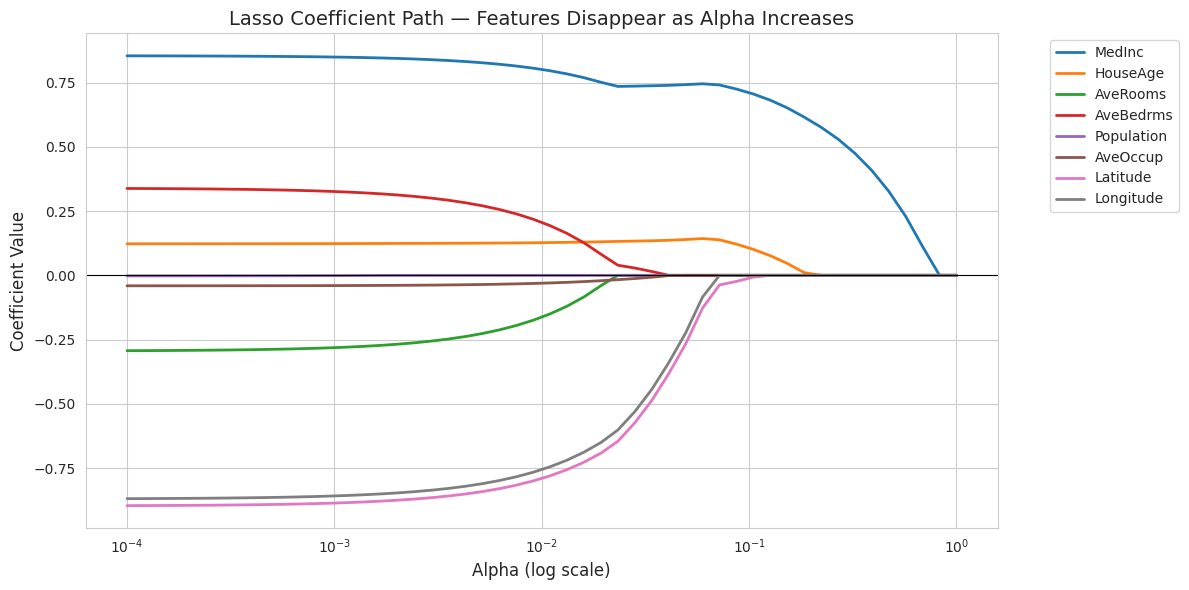

In [15]:
alpha_range = np.logspace(-4, 0, 50)
coef_paths = []

for alpha in alpha_range:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_reg_train_sc, y_reg_train)
    coef_paths.append(lasso.coef_.copy())

coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 6))
for i, feature in enumerate(X_reg.columns):
    plt.semilogx(alpha_range, coef_paths[:, i], linewidth=2, label=feature)

plt.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
plt.title('Lasso Coefficient Path — Features Disappear as Alpha Increases', fontsize=14)
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**What to observe — this plot tells a powerful story:**

- On the **far left** (very small alpha), all features have non-zero coefficients — the model is using everything.
- As we move **right** (increasing alpha), lines start hitting the zero axis one by one. Each time a line touches zero, that feature has been eliminated from the model.
- The **last feature standing** — the one that resists zeroing the longest — is the most important predictor. For California Housing, this is almost certainly `MedInc` (median income).
- Features that hit zero early are the least useful — the model can live without them.

This is Lasso's built-in **feature ranking**. You get it for free just by looking at this plot.


## 8. ElasticNet — The Best of Both Worlds

What if you want the feature selection ability of Lasso **and** the stability of Ridge? That is where **ElasticNet** comes in. It combines both L1 and L2 penalties:

$$\text{Cost}_{\text{ElasticNet}} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum |w_j| + \frac{(1-\rho)}{2} \sum w_j^2 \right]$$

Where:
- $\alpha$ controls the overall regularization strength
- $\rho$ (`l1_ratio` in Scikit-learn) controls the **mix** between L1 and L2:
  - `l1_ratio=1.0` → pure Lasso
  - `l1_ratio=0.0` → pure Ridge
  - `l1_ratio=0.5` → equal mix

**When to use ElasticNet:**
- When you have many correlated features (Lasso alone can be unstable — it might randomly pick one from a correlated group)
- When you want some feature selection but also stable coefficient estimates
- As a safe default when you are unsure whether Ridge or Lasso is better

**Task:** Fit ElasticNet with different l1_ratios and compare.

In [16]:
print(f"{'l1_ratio':<12} {'Mix':>18} {'Train R²':>10} {'Test R²':>10} {'Non-Zero':>10}")
print("-" * 62)

ratio_labels = {
    0.1: 'Mostly Ridge',
    0.5: 'Balanced',
    0.9: 'Mostly Lasso'
}

for ratio in [0.1, 0.5, 0.9]:
    enet = ElasticNet(alpha=0.01, l1_ratio=ratio, max_iter=10000)
    enet.fit(X_reg_train_sc, y_reg_train)

    train_r2 = enet.score(X_reg_train_sc, y_reg_train)
    test_r2 = enet.score(X_reg_test_sc, y_reg_test)
    n_nonzero = np.sum(enet.coef_ != 0)

    print(f"{ratio:<12} {ratio_labels[ratio]:>18} {train_r2:>10.4f} {test_r2:>10.4f} {n_nonzero:>10}")

l1_ratio                    Mix   Train R²    Test R²   Non-Zero
--------------------------------------------------------------
0.1                Mostly Ridge     0.6109     0.5788          7
0.5                    Balanced     0.6101     0.5803          7
0.9                Mostly Lasso     0.6089     0.5814          7


**What to observe:**

- **l1_ratio=0.1 (Mostly Ridge):** All or most features survive. The Ridge component dominates, so coefficients are shrunk but not zeroed. Performance is close to plain Ridge.

- **l1_ratio=0.5 (Balanced):** Some features may start getting dropped. The model balances between Ridge's stability and Lasso's sparsity.

- **l1_ratio=0.9 (Mostly Lasso):** More features are zeroed out, similar to pure Lasso. The small Ridge component adds a bit of stability.

ElasticNet gives you a **dial** between Ridge and Lasso behavior. In practice, you tune both `alpha` and `l1_ratio` using cross-validation to find the best combination.


## 9. Ridge vs Lasso vs ElasticNet — Summary Comparison

Let us put all three side by side on the same dataset and compare their performance and behavior.

**Task:** Fit all three models and create a comparison table.

In [17]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Lasso (α=0.01)': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet (α=0.01)': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

results = []

for name, model in models.items():
    model.fit(X_reg_train_sc, y_reg_train)

    train_r2 = model.score(X_reg_train_sc, y_reg_train)
    test_r2 = model.score(X_reg_test_sc, y_reg_test)
    n_nonzero = np.sum(model.coef_ != 0)
    gap = train_r2 - test_r2

    results.append({
        'Model': name,
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'Non-Zero Features': n_nonzero,
        'R² Gap': round(gap, 4)
    })

results_df = pd.DataFrame(results)
print("=" * 72)
print("  MODEL COMPARISON — California Housing Dataset")
print("=" * 72)
print(results_df.to_string(index=False))
print("=" * 72)

  MODEL COMPARISON — California Housing Dataset
              Model  Train R²  Test R²  Non-Zero Features  R² Gap
  Linear Regression    0.6126   0.5758                  8  0.0368
      Ridge (α=0.1)    0.6126   0.5758                  8  0.0368
     Lasso (α=0.01)    0.6085   0.5816                  7  0.0269
ElasticNet (α=0.01)    0.6101   0.5803                  7  0.0298


**What to observe — walk through each row:**

- **Linear Regression** uses all 8 features and has some gap between train and test R². This is our baseline — no regularization at all.

- **Ridge** also uses all 8 features (it never zeros anything out), but the gap between train and test may be slightly smaller. Ridge shrinks coefficients but keeps them all. It is the most stable option when you believe all features are useful.

- **Lasso** uses fewer features — it has dropped some by zeroing their coefficients. Despite using fewer features, its test R² is often very close to (or even matches) the full model. This demonstrates that the dropped features were not contributing meaningful information.

- **ElasticNet** falls in between — it drops some features (from the L1 component) while keeping the remaining coefficients stable (from the L2 component).

In this particular dataset with only 8 features, the differences may be subtle. The benefit of regularization becomes much more dramatic when you have many more features, polynomial expansions, or complex feature engineering.


## 10. Regularization in Classification — Logistic Regression

Everything we have discussed applies to Logistic Regression as well. In fact, Scikit-learn's `LogisticRegression` has **regularization built in by default** — the parameter `C` controls it.

**Important:** In Scikit-learn's LogisticRegression, regularization is controlled by `C`, which is the **inverse** of alpha:

$$C = \frac{1}{\alpha}$$

- **Small C** (e.g., 0.01) → strong regularization (more penalty, simpler model)
- **Large C** (e.g., 100) → weak regularization (less penalty, more complex model)

You can also choose the penalty type:
- `penalty='l2'` → Ridge-style regularization (default)
- `penalty='l1'` → Lasso-style regularization (requires `solver='liblinear'` or `solver='saga'`)
- `penalty='elasticnet'` → ElasticNet (requires `solver='saga'` and `l1_ratio`)

### 10.1 Effect of C on Logistic Regression

Let us use the Breast Cancer dataset from Day 48 and see how different values of C affect the model's performance and coefficients.

**Task:** Load the Breast Cancer data, scale it, and fit Logistic Regression with different C values.

In [18]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
X_clf = cancer.data
y_clf = cancer.target

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_clf_train_sc = scaler_clf.fit_transform(X_clf_train)
X_clf_test_sc = scaler_clf.transform(X_clf_test)

print(f"Breast Cancer Dataset loaded")
print(f"  Training set: {X_clf_train_sc.shape[0]} samples, {X_clf_train_sc.shape[1]} features")
print(f"  Test set:     {X_clf_test_sc.shape[0]} samples")
print(f"  Classes: 0=Malignant, 1=Benign")

Breast Cancer Dataset loaded
  Training set: 455 samples, 30 features
  Test set:     114 samples
  Classes: 0=Malignant, 1=Benign


In [19]:
c_values = [0.01, 0.1, 1.0, 10, 100]

print(f"{'C':<8} {'Reg Strength':>14} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Non-Zero':>10}")
print("-" * 64)

for c in c_values:
    lr = LogisticRegression(C=c, random_state=42, max_iter=5000)
    lr.fit(X_clf_train_sc, y_clf_train)

    train_acc = accuracy_score(y_clf_train, lr.predict(X_clf_train_sc))
    test_acc = accuracy_score(y_clf_test, lr.predict(X_clf_test_sc))
    n_nonzero = np.sum(lr.coef_[0] != 0)
    gap = train_acc - test_acc

    strength = 'Very Strong' if c <= 0.01 else 'Strong' if c <= 0.1 else 'Default' if c == 1.0 else 'Weak' if c <= 10 else 'Very Weak'

    print(f"{c:<8} {strength:>14} {train_acc:>10.4f} {test_acc:>10.4f} {gap:>8.4f} {n_nonzero:>10}")

C          Reg Strength  Train Acc   Test Acc      Gap   Non-Zero
----------------------------------------------------------------
0.01        Very Strong     0.9560     0.9474   0.0087         30
0.1              Strong     0.9868     0.9737   0.0131         30
1.0             Default     0.9890     0.9825   0.0066         30
10                 Weak     0.9912     0.9649   0.0263         30
100           Very Weak     0.9934     0.9474   0.0460         30


**What to observe — walk through the pattern:**

- At **C=0.01** (very strong regularization), both train and test accuracy may be lower — the model is being forced to be very simple, possibly too simple. But the gap between them is small. The model is regularized into stability at the cost of performance.

- As C increases to **1.0** (the default), both scores improve. The model has enough freedom to learn the patterns in the data without being overly constrained.

- At **C=10 and C=100** (weak regularization), the training accuracy might be slightly higher, but watch the gap — it may widen, indicating the beginning of overfitting. The model is given too much freedom.

- With the default L2 penalty, all 30 features remain non-zero regardless of C. The L2 penalty shrinks coefficients but never zeros them out — just like Ridge in regression.

The sweet spot for C is typically somewhere in the middle — strong enough to prevent overfitting, but not so strong that it prevents learning. The default C=1.0 is often a good starting point.


### 10.2 L1 Regularization in Logistic Regression — Feature Selection

Just like Lasso does for regression, L1 penalty in Logistic Regression can zero out coefficients and perform feature selection.

**Task:** Fit Logistic Regression with L1 penalty at different C values and see which features survive.

In [23]:
l1_c_values = [0.01, 0.1, 1.0]

for c in l1_c_values:
    lr_l1 = LogisticRegression(
        C=c,
        solver='saga',
        l1_ratio=1,        #  THIS means pure L1
        # penalty=None,      #  do NOT set penalty
        random_state=42,
        max_iter=5000
    )

    lr_l1.fit(X_clf_train_sc, y_clf_train)

    train_acc = accuracy_score(y_clf_train, lr_l1.predict(X_clf_train_sc))
    test_acc = accuracy_score(y_clf_test, lr_l1.predict(X_clf_test_sc))

    n_nonzero = np.sum(lr_l1.coef_[0] != 0)
    n_zero = 30 - n_nonzero

    surviving = [name for name, coef in zip(X_clf.columns, lr_l1.coef_[0]) if coef != 0]

    print("="*65)
    print(f"C = {c} | Train Acc = {train_acc:.4f} | Test Acc = {test_acc:.4f}")
    print(f"Features kept = {n_nonzero}, dropped = {n_zero}")


C = 0.01 | Train Acc = 0.8813 | Test Acc = 0.8860
Features kept = 3, dropped = 27
C = 0.1 | Train Acc = 0.9736 | Test Acc = 0.9737
Features kept = 8, dropped = 22
C = 1.0 | Train Acc = 0.9890 | Test Acc = 0.9912
Features kept = 18, dropped = 12


**What to observe**

- At **C=0.01** (strong L1 regularization), the vast majority of the 30 features are eliminated. Only a handful survive — these are the features that carry the most discriminative power for separating malignant from benign tumors. Look at which ones they are.

- At **C=0.1**, more features are kept, but still fewer than 30. The model is more expressive while still being selective about which features matter.

- At **C=1.0** (weaker regularization), most or all features survive. The L1 penalty is not strong enough to eliminate many.

The remarkable thing is the **accuracy**. Even with C=0.01, where only a few features survive, the test accuracy is often still quite high — sometimes within 1-2% of the full 30-feature model. This proves that many of the 30 features in this dataset are **redundant**. Remember the multicollinearity we discussed in Day 48? L1 regularization is one clean way to deal with it — it simply picks the most useful features and drops the rest.

This has practical implications: a model with 5 features is faster to train, easier to interpret, and less prone to overfitting than a model with 30 features — and it barely loses any accuracy.


## 11. How to Choose the Right Alpha / C — Cross-Validation Preview

We have been manually trying different alpha (or C) values and comparing. But in practice, how do you systematically choose the best one? The answer is **cross-validation** — a technique where we repeatedly split the training data into mini train/validation folds and average the performance across all folds.

Scikit-learn provides convenient built-in tools for this: `RidgeCV`, `LassoCV`, and `LogisticRegressionCV`. These automatically search over a range of alpha/C values and pick the one that gives the best cross-validated performance.

We will cover cross-validation in depth in a future lecture, but let us see a quick preview.

**Task:** Use RidgeCV and LassoCV to automatically find the best alpha.

In [37]:
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   LogisticRegression, RidgeCV, LassoCV)

alphas_cv = np.logspace(-4, 2, 50)

# RidgeCV
ridge_cv = RidgeCV(alphas=alphas_cv)
ridge_cv.fit(X_reg_train_sc, y_reg_train)
ridge_test_r2 = ridge_cv.score(X_reg_test_sc, y_reg_test)

print("=" * 55)
print("  RIDGECV — Automatic Alpha Selection")
print("=" * 55)
print(f"  Alphas searched:  {len(alphas_cv)} values from {alphas_cv[0]:.4f} to {alphas_cv[-1]:.1f}")
print(f"  Best alpha:       {ridge_cv.alpha_:.4f}")
print(f"  Test R²:          {ridge_test_r2:.4f}")
print(f"  Features used:    {np.sum(ridge_cv.coef_ != 0)} / {X_reg.shape[1]} (Ridge keeps all)")

# LassoCV
lasso_cv = LassoCV(alphas=alphas_cv, max_iter=10000, cv=5)
lasso_cv.fit(X_reg_train_sc, y_reg_train)
lasso_test_r2 = lasso_cv.score(X_reg_test_sc, y_reg_test)
n_nonzero_cv = np.sum(lasso_cv.coef_ != 0)

surviving_cv = [name for name, c in zip(X_reg.columns, lasso_cv.coef_) if c != 0]

print()
print("=" * 55)
print("  LASSOCV — Automatic Alpha Selection")
print("=" * 55)
print(f"  Alphas searched:  {len(alphas_cv)} values from {alphas_cv[0]:.4f} to {alphas_cv[-1]:.1f}")
print(f"  Best alpha:       {lasso_cv.alpha_:.4f}")
print(f"  Test R²:          {lasso_test_r2:.4f}")
print(f"  Features used:    {n_nonzero_cv} / {X_reg.shape[1]}")
print(f"  Surviving:        {', '.join(surviving_cv)}")

  RIDGECV — Automatic Alpha Selection
  Alphas searched:  50 values from 0.0001 to 100.0
  Best alpha:       1.9307
  Test R²:          0.5758
  Features used:    8 / 8 (Ridge keeps all)

  LASSOCV — Automatic Alpha Selection
  Alphas searched:  50 values from 0.0001 to 100.0
  Best alpha:       0.0007
  Test R²:          0.5766
  Features used:    8 / 8
  Surviving:        MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude


**What to observe:**

- **RidgeCV** searched through 50 different alpha values and automatically picked the one that gives the best cross-validated score. Notice the best alpha — it is the value that optimally balances the bias-variance trade-off for this data. Ridge keeps all features (as always), but with well-tuned shrinkage.

- **LassoCV** does the same search, but additionally performs feature selection. Check which features survived and which were dropped — these selections are validated through 5-fold cross-validation, making them more robust than our manual experiments.

- Compare their test R² scores. They should be competitive with the manual tuning we did earlier, but now the choice of alpha is **data-driven** rather than based on guesswork. In a real project, you would always use CV rather than manually picking alpha.

This is a preview of what we will explore in depth in a future lecture on cross-validation and hyperparameter tuning.

## 12. Other Ways to Combat Overfitting

Regularization is one of the most important tools, but it is not the only one. Here are other strategies that you will encounter throughout this course:

1. **More training data** — The simplest and most effective cure. More data makes it harder for the model to memorize noise.

2. **Feature selection** — Remove irrelevant or redundant features (we saw Lasso does this automatically).

3. **Cross-validation** — Use k-fold cross-validation to get a more reliable estimate of model performance and to tune hyperparameters.

4. **Early stopping** — For iterative algorithms (like gradient descent), stop training before the model has fully converged on the training data.

5. **Dropout** (for neural networks) — Randomly disable neurons during training to prevent co-adaptation.

6. **Ensemble methods** — Combine multiple models (like Random Forest or Gradient Boosting) to reduce variance.

7. **Simpler model architecture** — Sometimes a simpler model is genuinely better.

We will explore many of these techniques in detail in future lectures.